In [1]:
import numpy as np
import numpy.linalg as npla
import scipy.linalg as spla
import scipy.stats as st
import math
import time
import random as rd
import matplotlib.pyplot as plt
import os

In [2]:
# Required inputs

M = 20

specs = 'dense'
# specs = 'sparse'

T_list = [1000, 5000, 10000]
runs = 500

In [3]:
global alphabet

alphabet = ['A','B','C','D','E','F','G','H','I','J']#,'K','L','M','N','O','P','Q','R','S','T']
alphabet_length = len(alphabet)
for k in range(M-alphabet_length):
    alphabet.append(str(k))
M = len(alphabet)

In [4]:
class def_episode:
    def __init__(self, evnts, edge_set):#, lastevnt, pred, succ):
        self.freq = 0
        self.evnts = evnts.copy()
        self.edges = edge_set.copy()

In [5]:
# General Injective episodes with one maximal element

Ep_Events = []
episodes = []
structure = []

Ep_Events.append(list(['A','B']))
episodes.append(list([]))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B')})))
structure.append([])
structure[-1].append('A-B')


Ep_Events.append(list(['A','B','C']))
episodes.append(list([]))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('B','C')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','C'),('B','C')})))
structure.append([])
structure[-1].append('A-B-C')
structure[-1].append('(AB)-C')


Ep_Events.append(list(['A','B','C','D']))
episodes.append(list([]))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('B','C'),('B','D'),('C','D')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('B','D'),('C','D')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','D'),('B','D'),('C','D')})))
structure.append([])
structure[-1].append('A-B-C-D')
structure[-1].append('A-(BC)-D')
structure[-1].append('(ABC)-D')


Ep_Events.append(list(['A','B','C','D','E']))
episodes.append(list([]))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('A','E'),('B','C'),('B','D'),('B','E'),('C','D'),('C','E'),('D','E')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','C'),('A','D'),('A','E'),('B','C'),('B','D'),('B','E'),('C','E'),('D','E')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('A','E'),('B','E'),('C','E'),('D','E')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','E'),('B','E'),('C','E'),('D','E')})))
structure.append([])
structure[-1].append('A-B-C-D-E')
structure[-1].append('(AB)-(CD)-E')
structure[-1].append('A-(BCD)-E')
structure[-1].append('(ABCD)-E')


Ep_Events.append(list(['A','B','C','D','E','F']))
episodes.append(list([]))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('A','E'),('A','F'),('B','C'),('B','D'),('B','E'),('B','F'),('C','D'),('C','E'),('C','F'),('D','E'),('D','F'),('E','F')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('A','E'),('A','F'),('B','D'),('B','E'),('B','F'),('C','D'),('C','E'),('C','F'),('D','F'),('E','F')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','C'),('A','D'),('A','E'),('A','F'),('B','C'),('B','D'),('B','E'),('B','F'),('C','F'),('D','F'),('E','F')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('A','E'),('A','F'),('B','F'),('C','F'),('D','F'),('E','F')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','F'),('B','F'),('C','F'),('D','F'),('E','F')})))
structure.append([])
structure[-1].append('A-B-C-D-E-F')
structure[-1].append('A-(BC)-(DE)-F')
structure[-1].append('(AB)-(CDE)-F')
structure[-1].append('A-(BCDE)-F')
structure[-1].append('(ABCDE)-F')


Ep_Events.append(list(['A','B','C','D','E','F','G']))
episodes.append(list([]))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('A','E'),('A','F'),('A','G'),('B','C'),('B','D'),('B','E'),('B','F'),('B','G'),('C','D'),('C','E'),('C','F'),('C','G'),('D','E'),('D','F'),('D','G'),('E','F'),('E','G'),('F','G')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','G'),('B','G'),('C','G'),('D','G'),('E','G'),('F','G')})))
structure.append([])
structure[-1].append('A-B-C-D-E-F-G')
structure[-1].append('(ABCDEF)-G')


Ep_Events.append(list(['A','B','C','D','E','F','G','H']))
episodes.append(list([]))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('A','E'),('A','F'),('A','G'),('A','H'),('B','C'),('B','D'),('B','E'),('B','F'),('B','G'),('B','H'),('C','D'),('C','E'),('C','F'),('C','G'),('C','H'),('D','E'),('D','F'),('D','G'),('D','H'),('E','F'),('E','G'),('E','H'),('F','G'),('F','H'),('G','H')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','H'),('B','H'),('C','H'),('D','H'),('E','H'),('F','H'),('G','H')})))
structure.append([])
structure[-1].append('A-B-C-D-E-F-G-H')
structure[-1].append('(ABCDEFG)-H')

Ep_Events.append(list(['A','B','C','D','E','F','G','H','I']))
episodes.append(list([]))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('A','E'),('A','F'),('A','G'),('A','H'),('A','I'),('B','C'),('B','D'),('B','E'),('B','F'),('B','G'),('B','H'),('B','I'),('C','D'),('C','E'),('C','F'),('C','G'),('C','H'),('C','I'),('D','E'),('D','F'),('D','G'),('D','H'),('D','I'),('E','F'),('E','G'),('E','H'),('E','I'),('F','G'),('F','H'),('F','I'),('G','H'),('G','I'),('H','I')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','I'),('B','I'),('C','I'),('D','I'),('E','I'),('F','I'),('G','I'),('H','I')})))
structure.append([])
structure[-1].append('A-B-C-D-E-F-G-H-I')
structure[-1].append('(ABCDEFGH)-I')


Ep_Events.append(list(['A','B','C','D','E','F','G','H','I','J']))
episodes.append(list([]))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','B'),('A','C'),('A','D'),('A','E'),('A','F'),('A','G'),('A','H'),('A','I'),('A','J'),('B','C'),('B','D'),('B','E'),('B','F'),('B','G'),('B','H'),('B','I'),('B','J'),('C','D'),('C','E'),('C','F'),('C','G'),('C','H'),('C','I'),('C','J'),('D','E'),('D','F'),('D','G'),('D','H'),('D','I'),('D','J'),('E','F'),('E','G'),('E','H'),('E','I'),('E','J'),('F','G'),('F','H'),('F','I'),('F','J'),('G','H'),('G','I'),('G','J'),('H','I'),('H','J'),('I','J')})))
episodes[-1].append(def_episode(set(Ep_Events[-1]),set({('A','J'),('B','J'),('C','J'),('D','J'),('E','J'),('F','J'),('G','J'),('H','J'),('I','J')})))
structure.append([])
structure[-1].append('A-B-C-D-E-F-G-H-I-J')
structure[-1].append('(ABCDEFGHI)-J')

try:
    os.mkdir('./Results_NO_MAR')
except FileExistsError:
    print('already exists')

info  = ''
for ep_grp in range(len(episodes)):
    for ep_id in range(len(episodes[ep_grp])):
        info += 'Episode: '+ structure[ep_grp][ep_id] +'\n'
        info += 'Events: ' + str(episodes[ep_grp][ep_id].evnts) + '\n'
        info += 'Edges: ' + str(episodes[ep_grp][ep_id].edges) + '\n\n'
with open ('Results_NO_MAR/Episode_Info_unomax.txt', 'w') as f:
    f.write(info)

resultsfile = 'Results_NO_MAR/RunTime/NO_MAR_Results_M_'+str(M)+'_probs_'+str(specs)+'_unomax.txt'

In [6]:
class def_NOMDFA:
    def __init__(self):
        self.s = (set(),'')
        self.S = list([self.s])
        self.F = list()
        self.D = {}

In [7]:
def Construct_NOMDFA(alpha,prob):
    global alphabet
    alpha_size = len(alpha.evnts)
    pi = {}
    for e in alpha.evnts:
        pi[e] = set()
    for (e1,e2) in alpha.edges:
        pi[e2].add(e1)
    DFA = def_NOMDFA()
    n_states = 1
    for Q in DFA.S:
        DFA.D[str(Q)] = {}
        for ev in alphabet:
            if len(Q[0]) != alpha_size:
                Qs_new = Q[0].copy()
                Ql_new = ev
                if (ev in alpha.evnts):
                    if not (alpha.evnts-Q[0]).intersection(pi[ev]):
                        Qs_new.add(ev)
                if Q[1] == '' or prob[Q[1]][Ql_new] != 0:
                    Q_new = (Qs_new,Ql_new)
                    DFA.D[str(Q)][ev] = Q_new
                    if Q_new not in DFA.S:
                        DFA.S.append(Q_new)
            else:
                DFA.D[str(Q)][ev] = DFA.D[str(DFA.s)][ev]
            
#             print(DFA.D[str(Q)])
        if len(Q[0]) == alpha_size:
            DFA.F.append(Q)
    return DFA

In [8]:
def Print_Automata(DFA):
    print('DFA')
    print('start state: ', DFA.s)
    print('final state: ', DFA.F)
    print('\n')
    for Q in DFA.S:
        print('Current state: ', Q)
        print('Transitions:')
        for ev in DFA.D[str(Q)].keys():
            print(ev, ' : ', DFA.D[str(Q)][ev])
        print('\n')

In [9]:
def GetTransitionMatrix(DFA,prob):
    global final_states
    T0 = list()
    for state in DFA.S:
        T0.append([0]*len(DFA.S))
        for ev in DFA.D[str(state)].keys():
            if state[1] == '':
                T0[-1][DFA.S.index(DFA.D[str(state)][ev])] = 1/len(list(DFA.D[str(state)].keys())) #prob[DFA.S[final_states[0]][1]][ev]
            else:
                T0[-1][DFA.S.index(DFA.D[str(state)][ev])] = prob[state[1]][ev]
    return T0

In [10]:
def GetStats(T0,final_states):

    ndiags = len(T0)
    nfinals = len(final_states)
    
    if nfinals == 0:
        return(0,0)
    
    T = np.matrix(T0)
    L = np.eye(ndiags)

    dQdu = 0
    d2Qdu2 = 0
    for k1 in range(nfinals):
        L1 = L.copy()
        L1[final_states[k1],final_states[k1]] = 0
        dQdu += spla.det(L1-T)
        for k2 in range(k1+1,nfinals):
            L2 = L1.copy()
            L2[final_states[k2],final_states[k2]] = 0
            d2Qdu2 += spla.det(L2-T)
    d2Qdu2 *= 2

    dQdl = 0
    d2Qdl2 = 0
    d2Qdudl = 0
    for k1 in range(ndiags):
        T1 = T.copy()
        T1[:,k1] *= 0
        dQdl += spla.det(L-T1)
        for f1 in final_states:
            if k1 != f1:
                L1 = L.copy()
                L1[f1,f1] = 0
                d2Qdudl += spla.det(L1-T1)
        for k2 in range(k1+1,ndiags):
            T2 = T1.copy()
            T2[:,k2] *= 0
            d2Qdl2 += spla.det(L-T2)
    d2Qdl2 *= 2

#     print('dQ/du :', dQdu)
#     print('dQ/dl :', dQdl)
#     print('d2Q/du2 :',d2Qdu2)
#     print('d2Q/dl2 :',d2Qdl2)
#     print('d2Q/dudl :',d2Qdudl)

    lambda1 = -dQdu/dQdl
    lambda11 = -(d2Qdu2 + 2*lambda1*d2Qdudl + lambda1**2*d2Qdl2)/dQdl

    MX1 = lambda1
    VX1 = lambda11 + lambda1 - lambda1**2

    return MX1, VX1

In [11]:
def GetStats_Renewal(T0,final_states):

    nstates = len(T0)
    nfinals = len(final_states)
    
    if nfinals == 0:
        return(0,0)
    if nfinals != 1:
        return(-1,-1)
    f = final_states[0]
    
    T1 = np.matrix(T0)
#     print(T1,final_states)
    T1[:,final_states[0]] *= 0
    L = np.eye(nstates)
    
    m1 = npla.solve(L-T1,np.ones(nstates))
    m2 = npla.solve(L-T1,2*(m1-np.ones(nstates)))
#     m2 = npla.solve(L-T1,2*np.matmul(T1,m1).T)

    MX1 = m1[f]**(-1)
    VX1 = m1[f]**(-3)*(m2[f]-m1[f]**2+m1[f])

    return MX1, VX1

Episode:  A-B
Events:  {'B', 'A'}
Edges:  {('A', 'B')}
no of states:  40
no of final states:  1
0.025454650737245052 0.012069814257691741
Time taken (Ren):  0.06472897529602051 



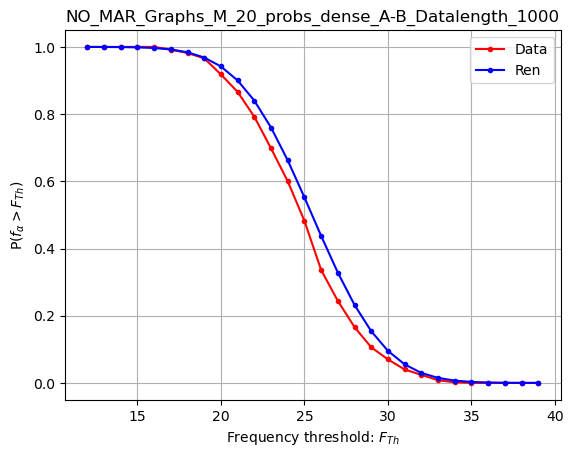

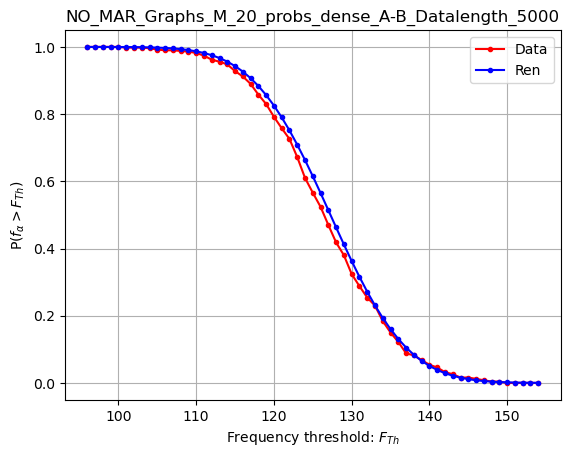

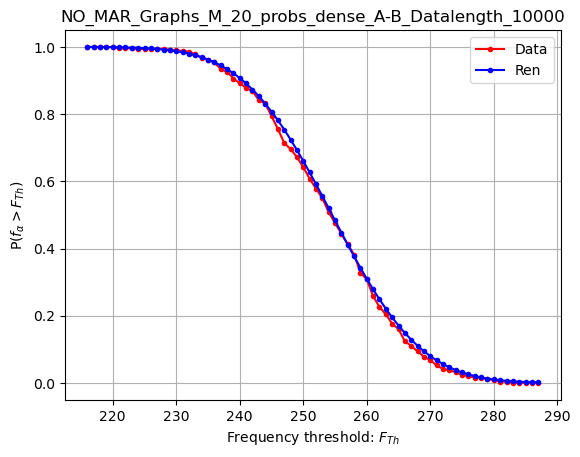

Episode:  A-B-C
Events:  {'C', 'B', 'A'}
Edges:  {('A', 'C'), ('A', 'B'), ('B', 'C')}
no of states:  59
no of final states:  1
0.01655888675015654 0.005133678081232568
Time taken (Ren):  0.005003213882446289 



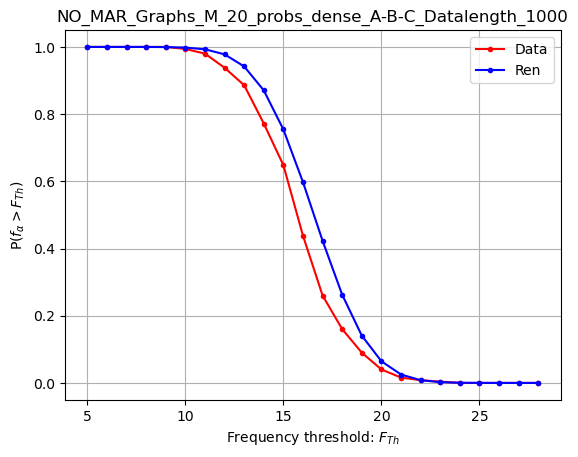

KeyboardInterrupt: 

In [12]:
Prob_Ep_Events = {}
if specs == 'equal':
    for k in range(len(alphabet)):
        Prob_Ep_Events[alphabet[k]] = {}
        for l in range(len(alphabet)):
            Prob_Ep_Events[alphabet[k]][alphabet[l]] = 1/len(alphabet)
else:
    saved_probs = np.load('Markov_M_'+str(M)+'_probs_'+str(specs)+'.npy')
    for k in range(len(alphabet)):
        Prob_Ep_Events[alphabet[k]] = {}
        for l in range(len(alphabet)):
            Prob_Ep_Events[alphabet[k]][alphabet[l]] = saved_probs[k,l]

        
try:
    os.mkdir('./Results_NO_MAR/Graphs')
except FileExistsError:
    print('already exists')
try:
    os.mkdir('./Results_NO_MAR/GraphData')
except FileExistsError:
    print('already exists')
try:
    os.mkdir('./Results_NO_MAR/RunTime')
except FileExistsError:
    print('already exists')

results = ''
for ep_grp in range(len(episodes)):
    for ep_id in range(len(episodes[ep_grp])):
        
        print('Episode: ', structure[ep_grp][ep_id])
        print('Events: ', episodes[ep_grp][ep_id].evnts)
        print('Edges: ', episodes[ep_grp][ep_id].edges)
        
        results += 'Episode: ' + structure[ep_grp][ep_id] + '\n'
        results += 'Events: ' + str(episodes[ep_grp][ep_id].evnts) + '\n'
        results += 'Edges: ' + str(episodes[ep_grp][ep_id].edges) + '\n'
        
        taaa = time.time()
        DFA = Construct_NOMDFA(episodes[ep_grp][ep_id],Prob_Ep_Events)
        
        final_states = list()
        for fstates in DFA.F:
            final_states.append(DFA.S.index(fstates))
        final_states.sort()
        
        T0 = GetTransitionMatrix(DFA,Prob_Ep_Events)
        tbbb = time.time()
        
        
        print('no of states: ', len(DFA.S))
        print('no of final states: ', len(DFA.F))


        results += 'no of states: ' + str(len(DFA.S)) + '\n'
        results += 'no of final states: ' + str(len(DFA.F)) + '\n'
        
#         tccc = time.time()
#         MX_SP, VX_SP = GetStats(T0, final_states)
#         tddd = time.time()
        
#         print(MX_SP, VX_SP)
#         print('Time taken (SP): ', tbbb-taaa+tddd-tccc)
#         results += '(SP): ' + 'mean = ' + str(MX_SP) + ', var = ' + str(VX_SP) + ', Time taken = ' + str(tbbb-taaa+tddd-tccc) + '\n'
        
        teee = time.time()
        MX_Ren, VX_Ren = GetStats_Renewal(T0, final_states)
        tfff = time.time()
        
        if MX_Ren != -1:
            print(MX_Ren, VX_Ren)
            print('Time taken (Ren): ', tbbb-taaa+tfff-teee, '\n')
            results += '(Ren): ' + 'mean = ' + str(MX_Ren) + ', var = ' + str(VX_Ren) + ', Time taken = ' + str(tbbb-taaa+tfff-teee) + '\n\n'

        
        
        for T in T_list:
            freq_list = list([])
            states = range(len(T0[0]))
            for run in range(runs):
                curr_state = [0]
                ep_freq = 0
                for ti in range(T):
                    curr_state = rd.choices(states, T0[curr_state[0]], k=1)
                    if curr_state[0] in final_states:
                        ep_freq += 1
                freq_list.append(ep_freq)
            freq_list.sort()
            fmax = max(freq_list)
            fmin = min(freq_list)

            
            x_vals = range(max(0,fmin-5),fmax+5)
            
            graph0 = list([])
            for kkk in x_vals:
                graph0.append(0)
                for freq in freq_list:
                    if freq > kkk:
                        graph0[-1] += 1
                graph0[-1] /= runs

#             graph1 = list([])
#             for kkk in x_vals:
#                 graph1.append(1-st.norm(loc = T*MX_SP , scale = math.sqrt(T*VX_SP)).cdf(kkk))
            
            if MX_Ren != -1:
                graph2 = list([])
                for kkk in x_vals:
                    graph2.append(1-st.norm(loc = T*MX_Ren , scale = math.sqrt(T*VX_Ren)).cdf(kkk))

            x_vals = range(max(0,fmin-5),fmax+5)
            plt.plot(x_vals, graph0, '.-r')
#             plt.plot(x_vals, graph1, '.-g')
            if MX_Ren != -1:
                plt.plot(x_vals, graph2, '.-b')
            plt.xlabel('Frequency threshold: $F_{Th}$')
            plt.ylabel(r'P$( f_\alpha > F_{Th} )$')
            if MX_Ren != -1:
#                 plt.legend(['Data', 'SP', 'Ren'])
                plt.legend(['Data', 'Ren'])
            else:
#                 plt.legend(['Data', 'SP'])
                plt.legend(['Data'])
            plt.title('NO_MAR_Graphs_M_'+str(M)+'_probs_'+str(specs)+'_'+structure[ep_grp][ep_id]+'_Datalength_' + str(T))
            plt.grid()
            plt.savefig('Results_NO_MAR/Graphs/NO_MAR_Graphs_M_'+str(M)+'_probs_'+str(specs)+'_'+structure[ep_grp][ep_id]+'_Datalength_' + str(T) + '.jpg')
            plt.show()
            
#             if MX_Ren != -1:
#                 graphs = 'Xaxis \t Data \t SP \t Ren\n'
#                 for k in range(len(x_vals)):
#                     graphs += str(x_vals[k]) +'\t' + str(graph0[k]) + '\t' + str(graph1[k]) + '\t' + str(graph2[k]) + '\n'
#                 filename = 'Results_NO_MAR/GraphData/NO_MAR_Graphs_M_' + str(M) +'_probs_'+str(specs)+ '_' +structure[ep_grp][ep_id]+'_Datalength_' + str(T) + '.txt'
#                 with open(filename, 'w') as f:
#                     f.write(graphs)
#             else:
#                 graphs = 'Xaxis \t Data \t SP\n'
#                 for k in range(len(x_vals)):
#                     graphs += str(x_vals[k]) +'\t' + str(graph0[k]) + '\t' + str(graph1[k]) + '\n'
#                 filename = 'Results_NO_MAR/GraphData/NO_MAR_Graphs_M_' + str(M) +'_probs_'+str(specs)+ '_' +structure[ep_grp][ep_id]+'_Datalength_' + str(T) + '.txt'
#                 with open(filename, 'w') as f:
#                     f.write(graphs)
                    
            if MX_Ren != -1:
                graphs = 'Xaxis \t Data \t Ren\n'
                for k in range(len(x_vals)):
                    graphs += str(x_vals[k]) +'\t' + str(graph0[k]) + '\t' + str(graph2[k]) + '\n'
            else:
                graphs = 'Xaxis \t Data \n'
                for k in range(len(x_vals)):
                    graphs += str(x_vals[k]) +'\t' + str(graph0[k]) + '\n'
            filename = 'Results_NO_MAR/GraphData/NO_MAR_Graphs_M_' + str(M) +'_probs_'+str(specs)+ '_' +structure[ep_grp][ep_id]+'_Datalength_' + str(T) + '.txt'
            with open(filename, 'w') as f:
                f.write(graphs)
        


with open(resultsfile,'w') as f:
    f.write(results)